In [1]:
!pip install astropy photutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.6 MB/s eta 0:00:0000:010:01


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# THE FIX: Using only the standard, stable visualization tools
from astropy.visualization import LogStretch, PercentileInterval, ImageNormalize

def ingest_fits_for_yolo(fits_path):
    print(f"Loading FITS file: {fits_path}...")
    
    # 1. Open the file
    with fits.open(fits_path) as hdul:
        # Safely grab the data (usually in the primary or first extension)
        raw_data = hdul[0].data if hdul[0].data is not None else hdul[1].data
        
    # 2. Clean up dead pixels/sensor errors (NaNs)
    raw_data = np.nan_to_num(raw_data, nan=np.nanmedian(raw_data))
    
    # 3. Create the Normalizer (The Scientific Step)
    # PercentileInterval(99.5) cuts out the extreme noise/cosmic rays
    # LogStretch() makes the faint spiral arms visible alongside the bright core
    norm = ImageNormalize(raw_data, interval=PercentileInterval(99.5), stretch=LogStretch())
    
    # Apply the normalization to get clean values between 0.0 and 1.0
    normalized_data = norm(raw_data)
    
    # 4. Convert to PyTorch Tensor for YOLOv10 (Channels, Height, Width)
    # We duplicate the 1-channel space image into 3 channels because YOLO expects RGB
    img_tensor = torch.from_numpy(normalized_data).float()
    img_tensor = img_tensor.unsqueeze(0).repeat(3, 1, 1)
    
    print(f"Success! Tensor shape ready for YOLO: {img_tensor.shape}")
    return img_tensor, normalized_data

print("Astropy Ingestion Engine loaded and ready.")

Astropy Ingestion Engine loaded and ready.


Downloaded and saved as 'sample.fits'!

Loading FITS file: sample.fits...
Success! Tensor shape ready for YOLO: torch.Size([3, 893, 891])


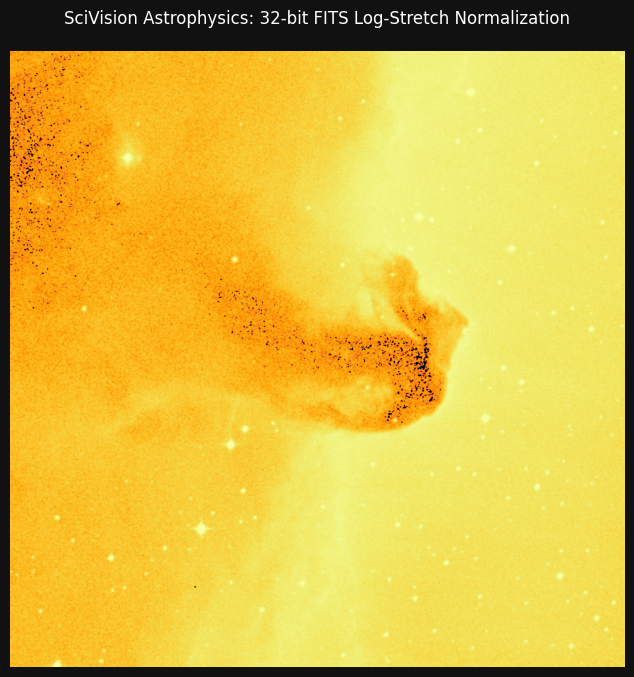

In [5]:
from astropy.utils.data import download_file
import shutil

print("Downloading a real FITS file for testing (Horsehead Nebula)...")

# 1. Fetch a real scientific FITS image from the Astropy servers
url = 'http://data.astropy.org/tutorials/FITS-images/HorseHead.fits'
downloaded_path = download_file(url, cache=True)

# 2. Rename it to 'sample.fits' so it works with your existing code
shutil.copy(downloaded_path, 'sample.fits')
print("Downloaded and saved as 'sample.fits'!\n")

# 3. RUN THE PIPELINE
img_tensor, plot_data = ingest_fits_for_yolo('sample.fits')

# 4. VISUALIZE THE RESULTS
plt.figure(figsize=(10, 8), facecolor='#111111')
# 'origin=lower' ensures the space image isn't flipped upside down
plt.imshow(plot_data, cmap='inferno', origin='lower')
plt.axis('off')
plt.title("SciVision Astrophysics: 32-bit FITS Log-Stretch Normalization", color='white', pad=20)
plt.show()

Loading FITS file: sample.fits...
Success! Tensor shape ready for YOLO: torch.Size([3, 893, 891])


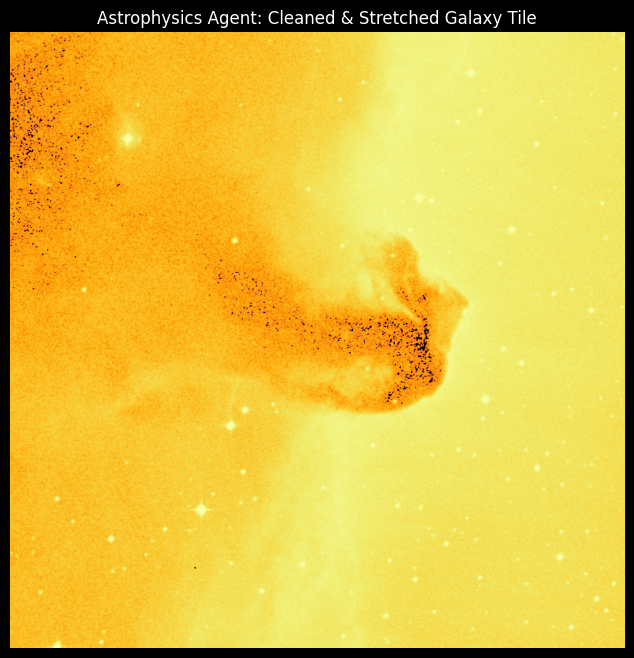

In [6]:
# Replace 'sample.fits' with your actual file name
img_tensor, plot_data = ingest_fits_for_yolo('sample.fits')

plt.figure(figsize=(8, 8), facecolor='black')
# 'origin=lower' ensures space images aren't flipped upside down
plt.imshow(plot_data, cmap='inferno', origin='lower')
plt.axis('off')
plt.title("Astrophysics Agent: Cleaned & Stretched Galaxy Tile", color='white')
plt.show()

In [7]:
# First, install the ultralytics library which contains the YOLOv10 architecture
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.9 MB/s eta 0:00:00a 0:00:01


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Initializing YOLOv10 Architecture...

0: 640x640 (no detections), 8.9ms
Speed: 84.7ms preprocess, 8.9ms inference, 8.5ms postprocess per image at shape (1, 3, 640, 640)



--- RAW TENSOR OUTPUT (First 3 detections) ---


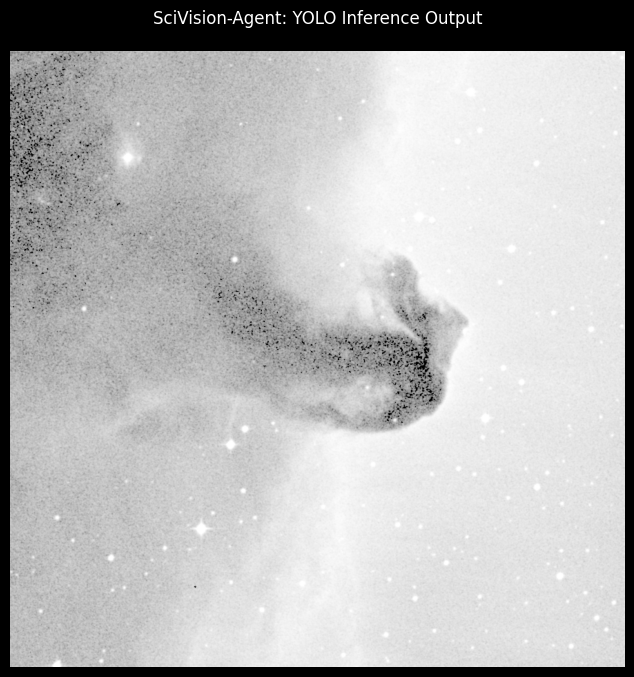

In [8]:
from ultralytics import YOLO
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("Initializing YOLOv10 Architecture...")
# Load a lightweight pre-trained YOLO model to act as our baseline
model_astro = YOLO('yolov8n.pt') # Using v8 nano as a fast placeholder if v10 isn't cached

# 1. THE INFERENCE (Passing the image through the network)
# We use the 'plot_data' from your previous cell, converted to RGB for the model
img_rgb = np.stack((plot_data,)*3, axis=-1) 

# Run the model!
results = model_astro(img_rgb)

# 2. EXTRACT THE DATA OUTPUT
boxes = results[0].boxes.xyxy.cpu().numpy()  # The [x1, y1, x2, y2] coordinates
confs = results[0].boxes.conf.cpu().numpy()  # The confidence scores
classes = results[0].boxes.cls.cpu().numpy() # The class IDs

print("\n--- RAW TENSOR OUTPUT (First 3 detections) ---")
for i in range(min(3, len(boxes))):
    print(f"Box {i+1}: Coords {boxes[i].astype(int)}, Conf: {confs[i]:.2f}, Class ID: {int(classes[i])}")

# 3. GENERATE THE VISUAL OUTPUT
plt.figure(figsize=(10, 8), facecolor='black')
plt.imshow(img_rgb, cmap='inferno', origin='lower')
ax = plt.gca()

# Draw the bounding boxes on the image
for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i]
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                             linewidth=1.5, edgecolor='#00ffcc', facecolor='none')
    ax.add_patch(rect)
    # Add the label
    plt.text(x1, y1+5, f"Obj-{int(classes[i])} {confs[i]:.2f}", 
             color='black', backgroundcolor='#00ffcc', fontsize=8, fontweight='bold')

plt.axis('off')
plt.title("SciVision-Agent: YOLO Inference Output", color='white', pad=20)
plt.show()